<a href="https://colab.research.google.com/github/tavishsood/Cantera-simulation/blob/main/Cantera.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install cantera

In [3]:
import cantera as ct
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
import cantera as ct
import pandas as pd
import numpy as np

gas = ct.Solution('gri30.yaml')
data = []

for i in range(1000):
    T_in = np.random.uniform(300, 1000)
    P_in = np.random.uniform(1, 50) * ct.one_atm
    phi = np.random.uniform(0.5, 1.5)

    gas.set_equivalence_ratio(phi, 'CH4', 'O2:1.0, N2:3.76')
    gas.TP = T_in, P_in

    gas.equilibrate('HP')

    data.append({
        'Inlet_T': T_in,
        'Pressure': P_in / ct.one_atm,
        'Phi': phi,
        'Final_T': gas.T,
        'CO_mole_frac': gas['CO'].X[0],
        'NO_mole_frac': gas['NO'].X[0]
    })

df = pd.DataFrame(data)
print(df.head)

<bound method NDFrame.head of         Inlet_T   Pressure       Phi      Final_T  CO_mole_frac  NO_mole_frac
0    769.762451  48.241805  0.852805  2418.791365  1.716748e-03      0.006602
1    630.782423  41.556720  1.163357  2411.281699  4.007600e-02      0.000229
2    942.374196  32.083690  1.363568  2495.484336  7.423132e-02      0.000167
3    827.078242  15.284688  0.957004  2545.787263  9.491182e-03      0.005278
4    699.328267  49.475077  1.289395  2362.065960  6.224945e-02      0.000070
..          ...        ...       ...          ...           ...           ...
995  400.879529  19.695923  0.529834  1615.475351  9.501324e-07      0.001345
996  486.160775  32.325409  0.817609  2164.137056  3.573099e-04      0.004428
997  953.847070  44.029673  0.524115  2054.728553  5.347758e-05      0.005720
998  990.574583  33.243233  1.393585  2512.777890  7.836081e-02      0.000165
999  700.549832  30.142584  0.774703  2254.927790  5.873414e-04      0.006036

[1000 rows x 6 columns]>


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error

X = df[['Inlet_T', 'Pressure', 'Phi']]
y = df[['Final_T', 'CO_mole_frac', 'NO_mole_frac']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Decision Tree": RandomForestRegressor(n_estimators=1, max_depth=10),
    "Random Forest": RandomForestRegressor(n_estimators=100),
    "SVR": MultiOutputRegressor(SVR()),
    "Gradient Boosting": MultiOutputRegressor(GradientBoostingRegressor())
}

# Comparison Table
comparison = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    comparison.append({"Model": name, "R2 Score": r2, "MAE": mae})

report_df = pd.DataFrame(comparison)
print(report_df)

               Model  R2 Score        MAE
0  Linear Regression  0.699854  46.132344
1              Ridge  0.699436  46.133559
2      Decision Tree  0.964306   9.308692
3      Random Forest  0.990372   4.304493
4                SVR -0.228197  54.507249
5  Gradient Boosting  0.996314   4.548231


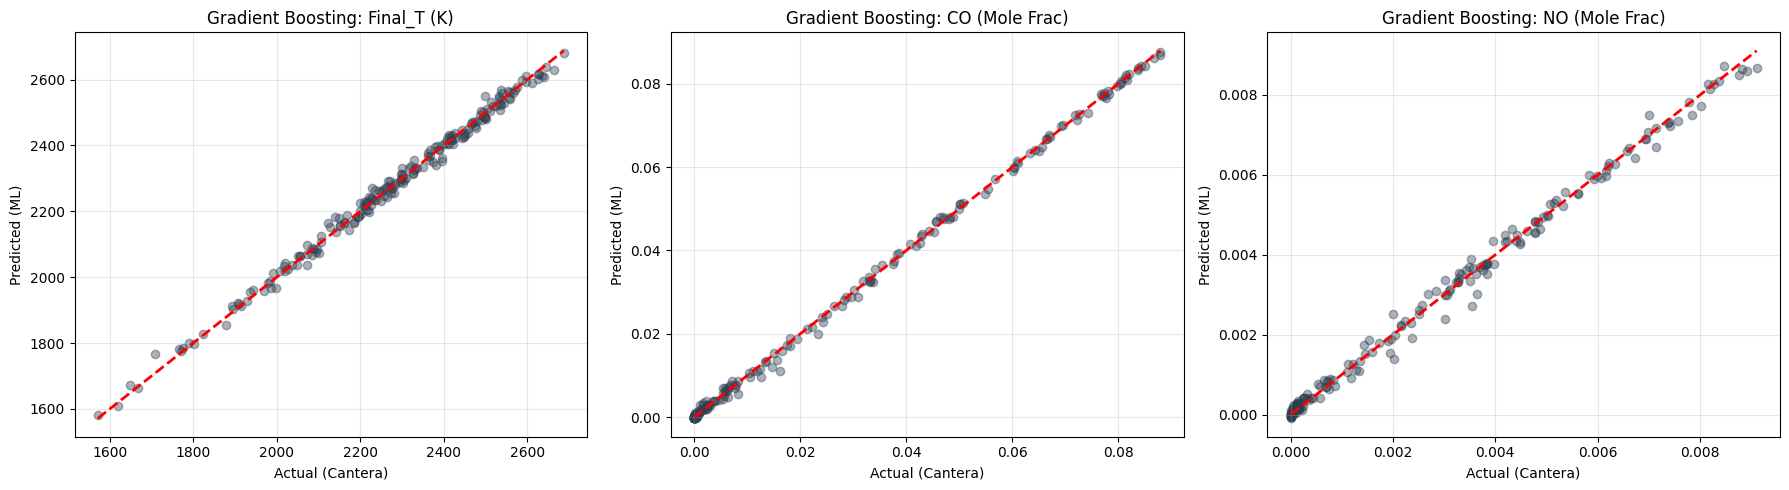

In [13]:
import matplotlib.pyplot as plt

best_model_name = report_df.sort_values(by="R2 Score", ascending=False).iloc[0]["Model"]
best_model = models[best_model_name]

y_pred = best_model.predict(X_test)
targets = ['Final_T (K)', 'CO (Mole Frac)', 'NO (Mole Frac)']

plt.figure(figsize=(18, 5))
for i, target in enumerate(targets):
    plt.subplot(1, 3, i+1)
    plt.scatter(y_test.iloc[:, i], y_pred[:, i], alpha=0.4, color='#2c3e50')

    low, high = y_test.iloc[:, i].min(), y_test.iloc[:, i].max()
    plt.plot([low, high], [low, high], color='red', linestyle='--', linewidth=2)

    plt.title(f'{best_model_name}: {target}')
    plt.xlabel('Actual (Cantera)')
    plt.ylabel('Predicted (ML)')
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('regression_analysis.png', dpi=300)
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(


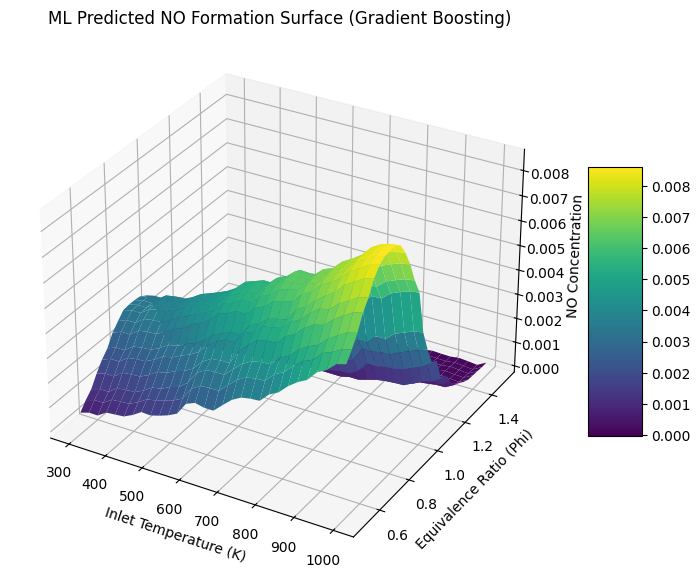

In [14]:
from mpl_toolkits.mplot3d import Axes3D

T_range = np.linspace(300, 1000, 30)
Phi_range = np.linspace(0.5, 1.5, 30)
T_grid, Phi_grid = np.meshgrid(T_range, Phi_range)
P_const = np.full(T_grid.shape, 25) # Constant Pressure at 25 atm

grid_input = np.c_[T_grid.ravel(), P_const.ravel(), Phi_grid.ravel()]
grid_pred = best_model.predict(grid_input)

NO_grid = grid_pred[:, 2].reshape(T_grid.shape)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(T_grid, Phi_grid, NO_grid, cmap='viridis', edgecolor='none')

ax.set_xlabel('Inlet Temperature (K)')
ax.set_ylabel('Equivalence Ratio (Phi)')
ax.set_zlabel('NO Concentration')
ax.set_title(f'ML Predicted NO Formation Surface ({best_model_name})')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)

plt.savefig('3d_surface_plot.png', dpi=300)
plt.show()

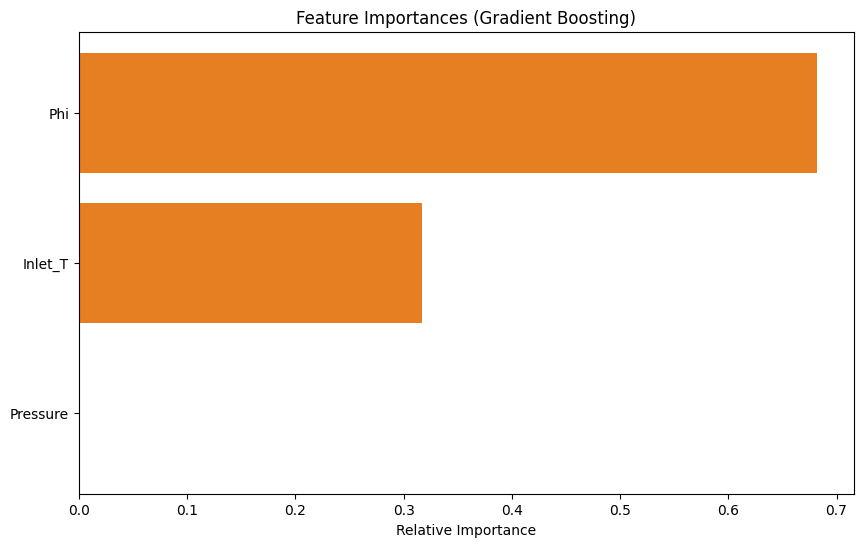

In [16]:
importances = best_model.estimators_[0].feature_importances_
features = X.columns
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title(f'Feature Importances ({best_model_name})')
plt.barh(range(len(indices)), importances[indices], color='#e67e22', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')

plt.savefig('feature_importance.png', dpi=300)
plt.show()